In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from joblib import dump
from h5py import File

import csiborgtools

%matplotlib inline
%load_ext autoreload
%autoreload 2


In [2]:
fpath = "/mnt/extraspace/rstiskalek/catalogs/PV_compilation.hdf5"
# fpath = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TFR.hdf5"

with File(fpath, 'r') as f:
    # mag  = f["w1"][...]
    # eta = f["lgWmxi"][...] - 2.5
    # Qw = f["Qw"][...]
    # RA = f["RA"][...] * 360 / 24
    # DEC = f["DE"][...]
    # print(f.keys())
    RA = f["2MTF/RA"][...]
    DEC = f["2MTF/DEC"][...]

# m = (mag > 5) & (Qw == 5)
# mag, eta = mag[m], eta[m]
# RA, DEC = RA[m], DEC[m]



RA = np.hstack([RA] * 5)
DEC = np.hstack([DEC] * 5)

In [18]:
!rm /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/*


reader = csiborgtools.read.Carrick2015Field()
velocity = reader.velocity_field()
boxsize = csiborgtools.simname2boxsize("Carrick2015")

# mean_mag = 10.31
# std_mag = 0.83
mean_mag, std_mag = 13.4, 0.5
mean_eta, std_eta = 0.0013264308311763035, 0.1565672419944486
a_TF = -21.5
b_TF = -3
h = 1.0
beta = 0.0
nrepeat_calibration = 2

kmax = 1
seed = 42

a_TF_dipole = np.asarray([-0.02818924,  0.05263123, 0.00594312])

for k in trange(kmax):
    mock, truths = csiborgtools.flow.mock_Carrick2MTF(
        velocity, boxsize, RA, DEC,
        Vext=np.asarray([-80, 0, -180]) / 2,
        mean_mag=mean_mag, std_mag=std_mag,
        mean_eta=mean_eta, std_eta=std_eta,
        h=h, a_TF=a_TF, b_TF=b_TF, sigma_TF=0.2,
        sigma_cal=0.05, sigma_v=250,
        nrepeat_calibration=nrepeat_calibration, beta=beta,
        a_TF_dipole=a_TF_dipole,
        calibration_max_percentile=None, calibration_rand_fraction=None,
        seed=seed, verbose=True, return_truths=True)
    seed += 1

    fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed{k}.hdf5"  # noqa
    print("Saving to ", fname)
    with File(fname, 'w') as f:
        for key in mock.keys():
            f.create_dataset(key, data=mock[key])

    fname_truths = fname.replace(".hdf5", "_truths.pkl")
    dump(truths, fname_truths)

100%|██████████| 1/1 [00:00<00:00, 14.01it/s]

[1.00000000e-04 6.00400400e-04 1.10080080e-03 1.60120120e-03
 2.10160160e-03 2.60200200e-03 3.10240240e-03 3.60280280e-03
 4.10320320e-03 4.60360360e-03 5.10400400e-03 5.60440440e-03
 6.10480480e-03 6.60520521e-03 7.10560561e-03 7.60600601e-03
 8.10640641e-03 8.60680681e-03 9.10720721e-03 9.60760761e-03
 1.01080080e-02 1.06084084e-02 1.11088088e-02 1.16092092e-02
 1.21096096e-02 1.26100100e-02 1.31104104e-02 1.36108108e-02
 1.41112112e-02 1.46116116e-02 1.51120120e-02 1.56124124e-02
 1.61128128e-02 1.66132132e-02 1.71136136e-02 1.76140140e-02
 1.81144144e-02 1.86148148e-02 1.91152152e-02 1.96156156e-02
 2.01160160e-02 2.06164164e-02 2.11168168e-02 2.16172172e-02
 2.21176176e-02 2.26180180e-02 2.31184184e-02 2.36188188e-02
 2.41192192e-02 2.46196196e-02 2.51200200e-02 2.56204204e-02
 2.61208208e-02 2.66212212e-02 2.71216216e-02 2.76220220e-02
 2.81224224e-02 2.86228228e-02 2.91232232e-02 2.96236236e-02
 3.01240240e-02 3.06244244e-02 3.11248248e-02 3.16252252e-02
 3.21256256e-02 3.262602

In [19]:
mock["r"].max()

291.8209159251867

In [113]:
np.linalg.norm(3 * np.asarray([-0.02818924,  0.05263123, 0.00594312]))

0.18000000746062236

In [114]:
len(mock['r'])

6240

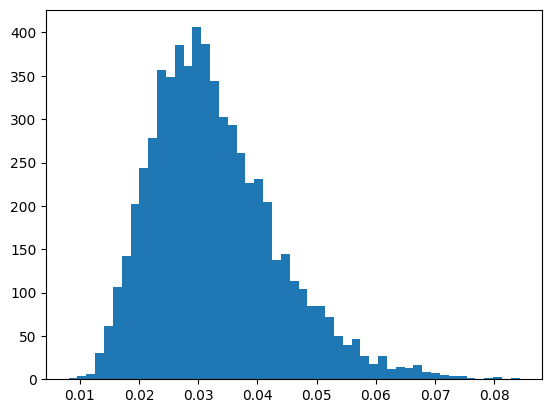

In [ ]:
plt.figure()
plt.hist(mock["r"], bins="auto")

plt.show()